In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from langdetect import detect, LangDetectException

In [2]:
from src.baseline import config, constants

In [3]:
embeddings_path = config.MODEL_DIR / constants.NOMIC_EMBEDDINGS_FILENAME

In [4]:
embeddings_dict = joblib.load(embeddings_path)

In [5]:
descriptions_df = pd.read_csv('/Users/daniilogorodnikov/PycharmProjects/nto-ai-25-26-team-baseline/data/raw/book_descriptions.csv')

In [11]:
book_ids = list(embeddings_dict.keys())
embeddings = np.array(list(embeddings_dict.values()))

In [6]:
genres_path = '/Users/daniilogorodnikov/PycharmProjects/nto-ai-25-26-team-baseline/data/raw/book_genres.csv'  # Adjust path as needed; assume CSV format for this example
genres_df = pd.read_csv(genres_path)

In [7]:
unique_genres = genres_df[['book_id', 'genre_id']].drop_duplicates(subset=['book_id'])

In [9]:
genre_map = dict(zip(unique_genres['book_id'], unique_genres['genre_id']))

In [12]:
book_genres = [genre_map.get(book_id, -1) for book_id in book_ids]

In [13]:
book_genres_str = [str(genre) for genre in book_genres]

In [14]:
label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(book_genres_str)

In [15]:
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

In [16]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_scaled)

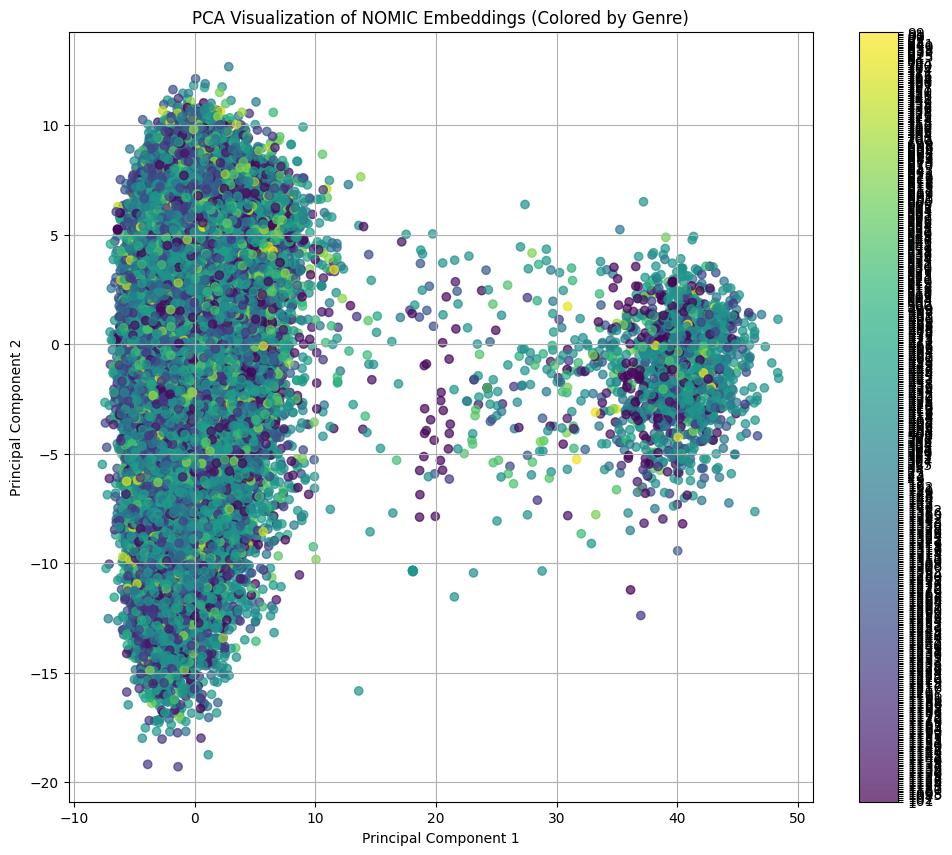

In [17]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=numerical_labels, cmap='viridis', alpha=0.7)
plt.title('PCA Visualization of NOMIC Embeddings (Colored by Genre)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(len(label_encoder.classes_)), format=plt.FuncFormatter(lambda i, *args: label_encoder.classes_[int(i)]))
plt.grid(True)
plt.savefig('pca_visualization_genre_colored.png')  # Save the plot to a file
plt.show()

In [19]:
unique_genres = genres_df[['book_id', 'genre_id']].drop_duplicates(subset=['book_id'])

In [21]:
genre_counts = unique_genres['genre_id'].value_counts()

In [22]:
total_books = len(unique_genres)
genre_percentages = (genre_counts / total_books) * 100

In [23]:
top_n = 10
top_genres_percent = genre_percentages.head(top_n)

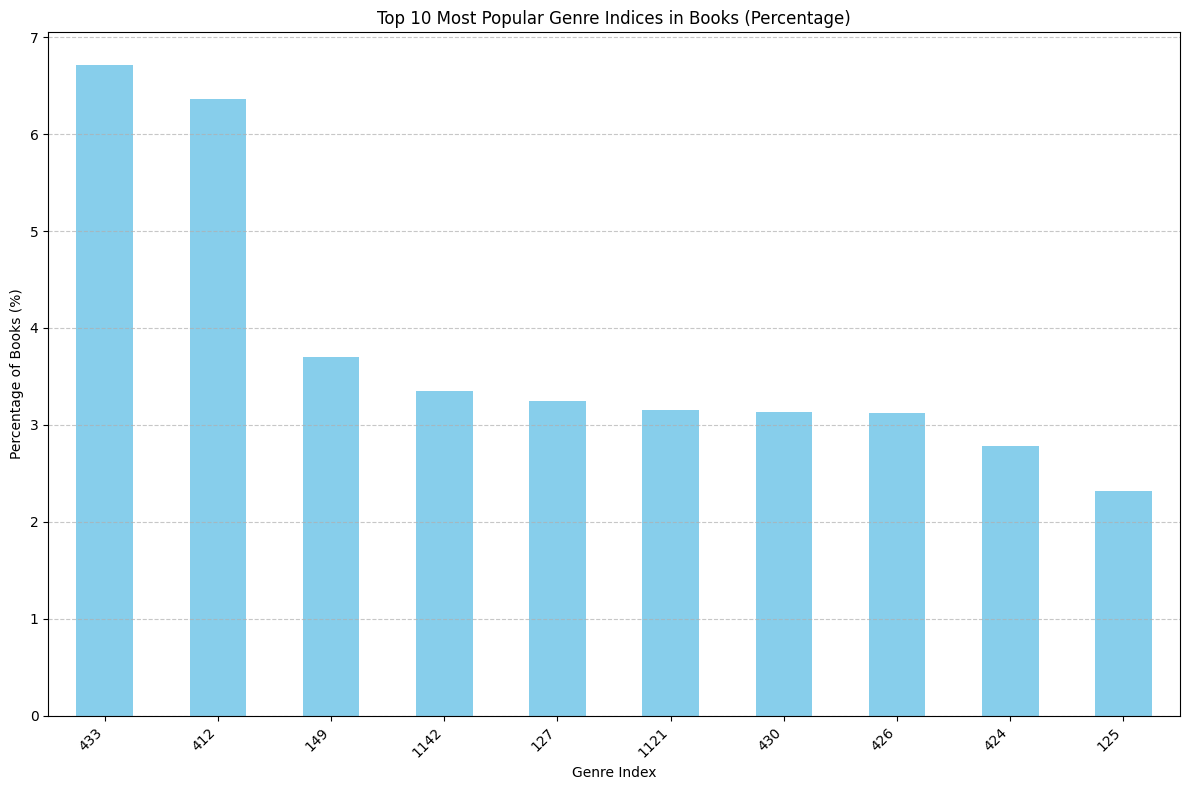

In [24]:
plt.figure(figsize=(12, 8))
top_genres_percent.plot(kind='bar', color='skyblue')
plt.title(f'Top {top_n} Most Popular Genre Indices in Books (Percentage)')
plt.xlabel('Genre Index')
plt.ylabel('Percentage of Books (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_genres_percentage_bar_graph.png')  # Save the plot to a file
plt.show()  # Display the plot if running in an interactive environment

In [30]:
bottom_n = 50
bottom_genres_percent = genre_percentages.tail(bottom_n)

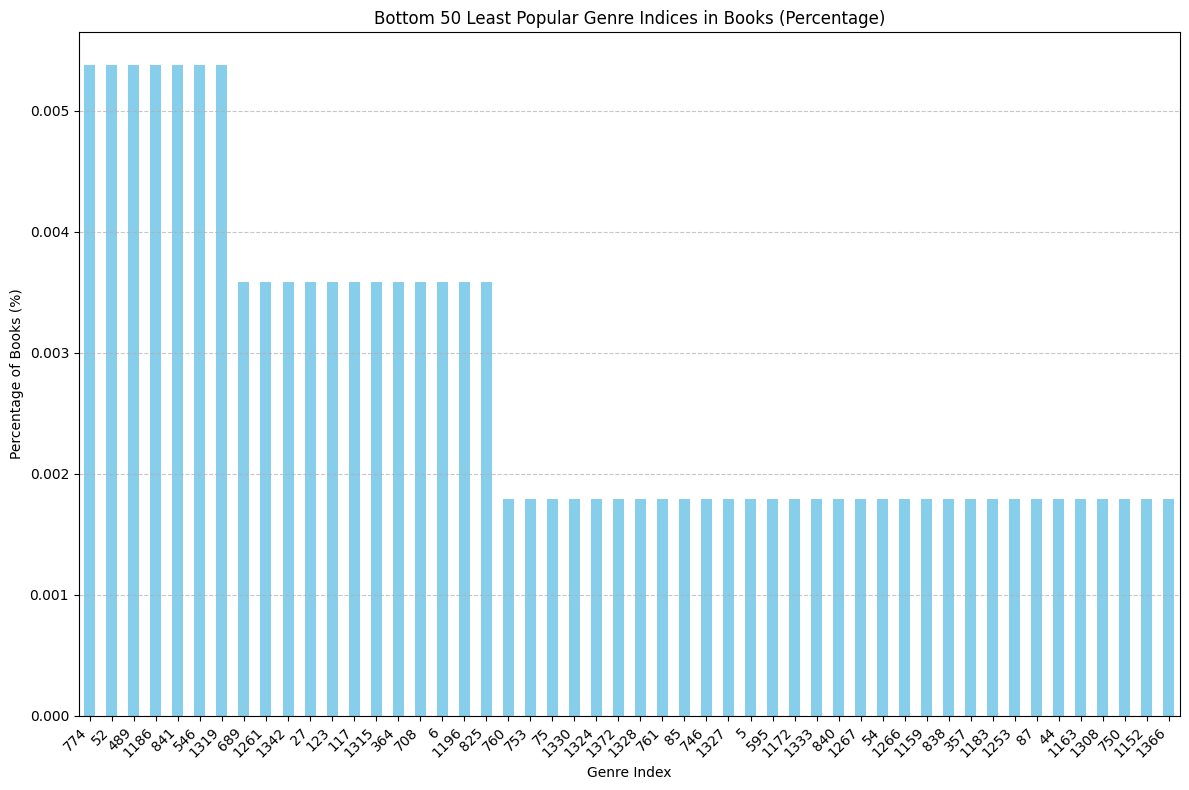

In [31]:
plt.figure(figsize=(12, 8))
bottom_genres_percent.plot(kind='bar', color='skyblue')
plt.title(f'Bottom {bottom_n} Least Popular Genre Indices in Books (Percentage)')
plt.xlabel('Genre Index')
plt.ylabel('Percentage of Books (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bottom_genres_percentage_bar_graph.png')  # Save the plot to a file
plt.show()  # Display the plot if running in an interactive environment